# Bank Churn Analysis by Taban 
## ITESO 2026 Semester One (1)
## Data Laboratory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, roc_auc_score
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('ggplot')

seed = 28
path = '.'

In [2]:
df = pd.read_csv('db_pap3.csv')
df.head()

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,768805383,1,45,M,3,High School,Married,5833.333333333333,Blue,39,5,1,3,12691.0,777,1144,42
1,818770008,1,49,F,5,Graduate,Single,1666.6666666666667,Blue,44,6,1,2,8256.0,864,1291,33
2,713982108,1,51,M,3,Graduate,Married,8333.333333333334,Blue,36,4,1,0,3418.0,0,1887,20
3,769911858,1,40,F,4,High School,Unknown,1666.6666666666667,Blue,34,3,4,1,3313.0,2517,1171,20
4,709106358,1,40,M,3,Uneducated,Married,5833.333333333333,Blue,21,5,1,0,4716.0,0,816,28


In [ ]:
##!pip install ydata-profiling
##!pip install ydata-profiling
## yprofiling -- dataset EDA.. I HAVE THE LOCAL FILE ON MY PC .. HTML FILE - JUST IN CASE 
## i saw the technique last week on the Youtube

In [4]:
### yprofiling report ...
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Bank Churn Analysis Report", explorative=True)

profile.to_file("analysis_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████| 17/17 [00:01<00:00, 14.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 1. Descriptive and Grouped Analysis

### 1a. General overview of the dataset

In [42]:
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)

Shape: (10127, 17)

Dtypes:
clientnum                     int64
client_stayed                 int64
customer_age                  int64
gender                          str
dependent_count               int64
education_level                 str
marital_status                  str
income_category                 str
card_category                   str
months_on_book                int64
total_relationship_count      int64
months_inactive_12_mon        int64
contacts_count_12_mon         int64
credit_limit                float64
total_revolving_bal           int64
total_trans_amt               int64
total_trans_ct                int64
dtype: object


We have 10,127 rows and 17 columns. The dataset contains a mix of numeric and categorical variables. The response variable is `client_stayed` (1 = stayed, 0 = left).

In [43]:
df.describe()

,clientnum,client_stayed,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,0.839340,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,4404.086304,64.858695
std,3.690378e+07,0.367235,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,3397.129254,23.472570
min,7.080821e+08,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,510.000000,10.000000
25%,7.130368e+08,1.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,2155.500000,45.000000
50%,7.179264e+08,1.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3899.000000,67.000000
75%,7.731435e+08,1.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,4741.000000,81.000000
max,8.283431e+08,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,18484.000000,139.000000


### 1b. Shortcomings of the database: missing values and poorly presented information

In [44]:
print('Null values per column:')
print(df.isnull().sum())

Null values per column:
clientnum                   0
client_stayed               0
customer_age                0
gender                      0
dependent_count             0
education_level             0
marital_status              0
income_category             0
card_category               0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
credit_limit                0
total_revolving_bal         0
total_trans_amt             0
total_trans_ct              0
dtype: int64


There are no explicit NaN values, however the categorical columns `education_level`, `marital_status` and `income_category` contain the label `'Unknown'`, which effectively represents missing information. The `income_category` column also stores income as a raw decimal number string (e.g. `'5833.333333333333'`) instead of a readable range, which suggests it was stored incorrectly and needs to be converted to numeric. The `clientnum` column is an ID and carries no predictive value.

In [45]:
# Count 'Unknown' ....
cat_cols = ['education_level', 'marital_status', 'income_category']
for col in cat_cols:
    unknown_count = (df[col] == 'Unknown').sum()
    pct = unknown_count / len(df) * 100
    print(f'{col}: {unknown_count} unknowns ({pct:.2f}%)')

education_level: 1519 unknowns (15.00%)
marital_status: 749 unknowns (7.40%)
income_category: 1112 unknowns (10.98%)


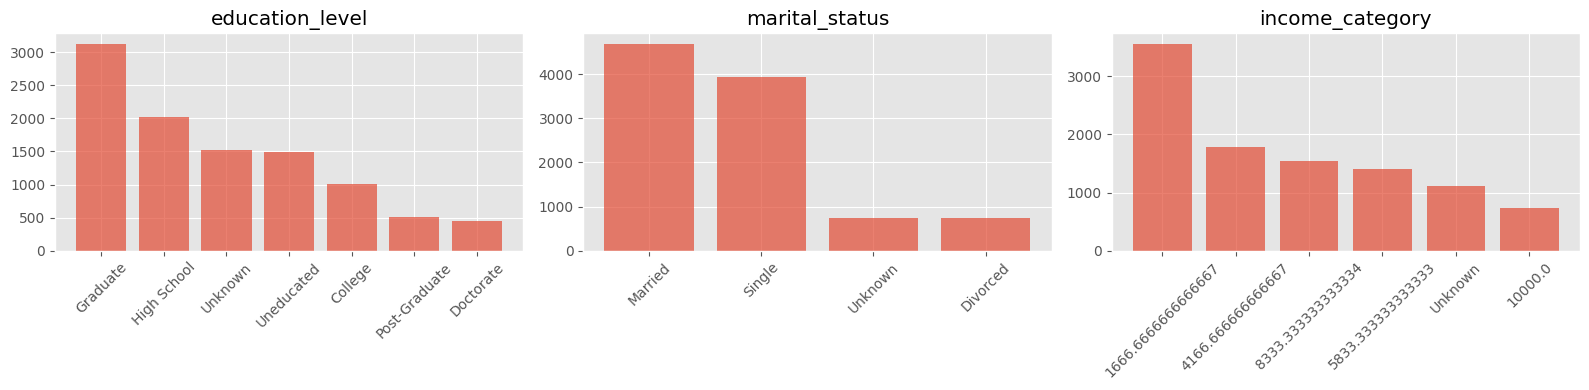

In [46]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, alpha=0.7)
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

We can observe that `education_level` has 1,519 unknowns (15%), `marital_status` has 749 (7.4%), and `income_category` has 1,112 (10.9%). These are non-trivial proportions that need to be addressed in the preprocessing step.

### 1c. Response variable distribution

client_stayed distribution:
  1: 8500 (83.9%)
  0: 1627 (16.1%)


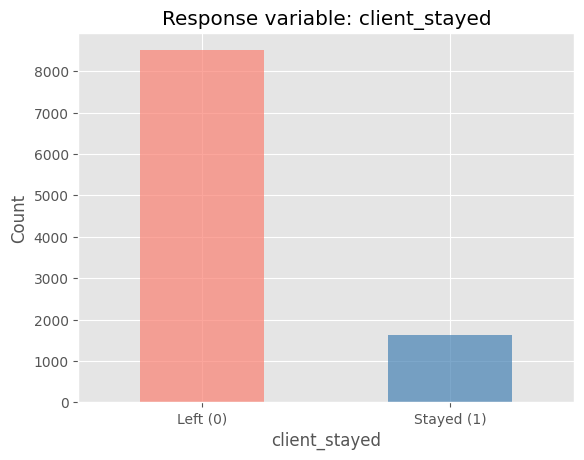

In [47]:
counts = df['client_stayed'].value_counts()
pcts = df['client_stayed'].value_counts(normalize=True) * 100

print('client_stayed distribution:')
for k in counts.index:
    print(f'  {k}: {counts[k]} ({pcts[k]:.1f}%)')

counts.plot(kind='bar', alpha=0.7, color=['salmon', 'steelblue'])
plt.title('Response variable: client_stayed')
plt.xticks([0, 1], ['Left (0)', 'Stayed (1)'], rotation=0)
plt.ylabel('Count')
plt.show()

The dataset is highly imbalanced: ~83.9% of clients stayed (1) and only ~16.1% left (0). This imbalance is important to keep in mind when evaluating models, as accuracy alone would be a misleading metric.

### 1d. Numeric variable distributions

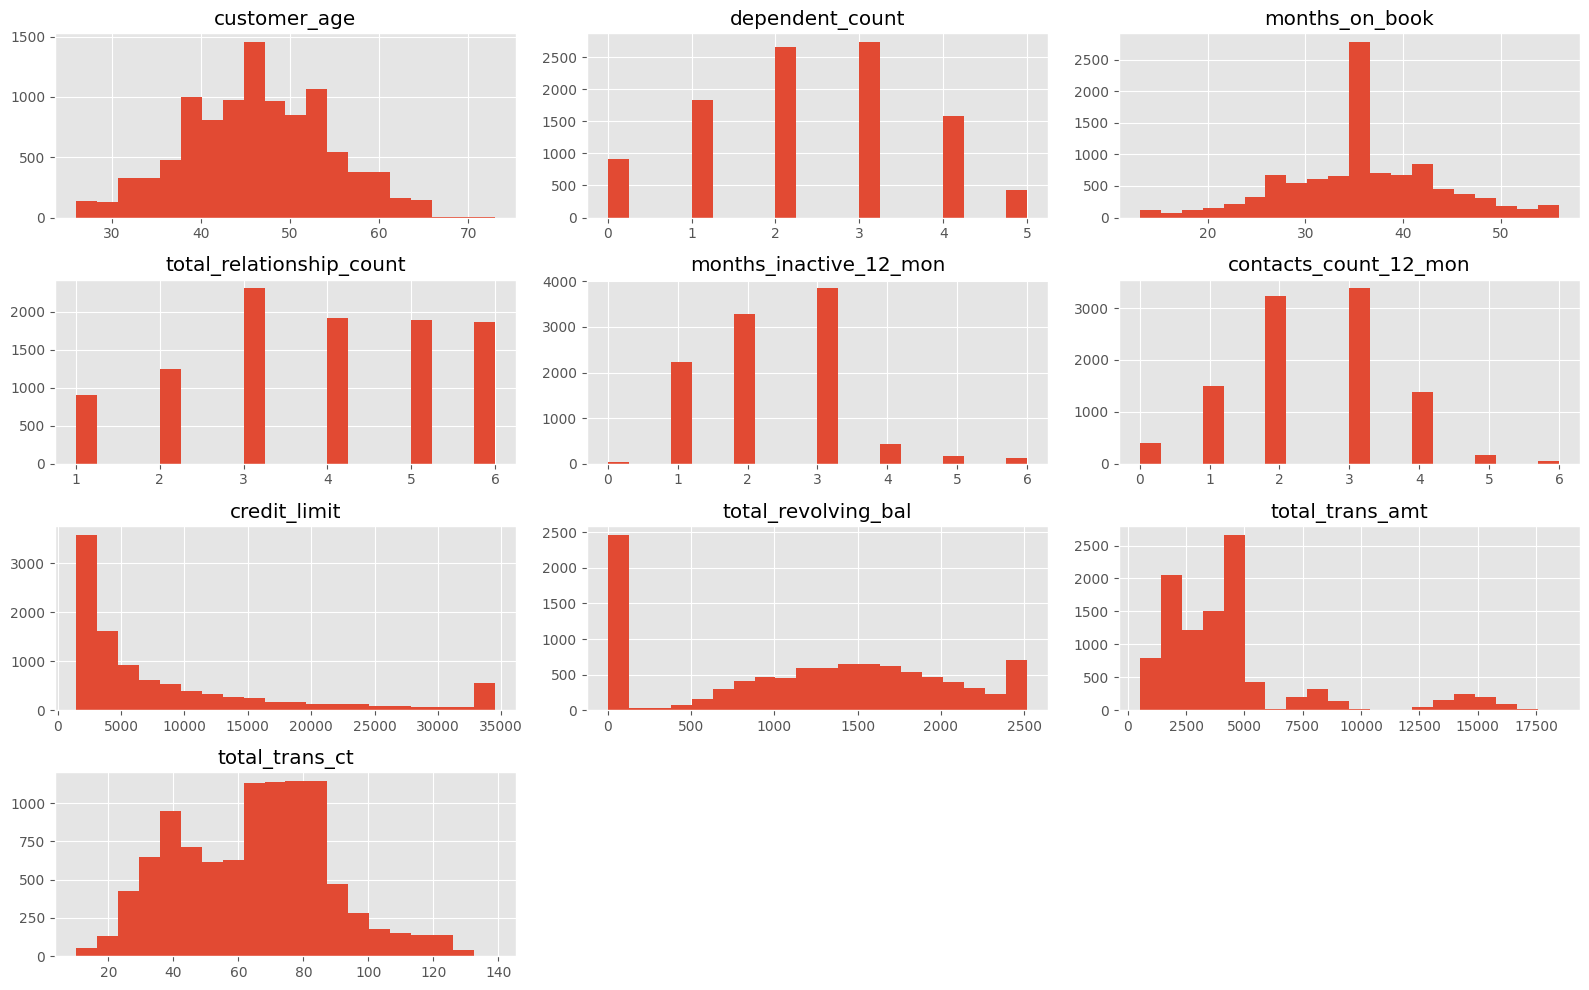

In [48]:
num_cols = ['customer_age', 'dependent_count', 'months_on_book',
            'total_relationship_count', 'months_inactive_12_mon',
            'contacts_count_12_mon', 'credit_limit',
            'total_revolving_bal', 'total_trans_amt', 'total_trans_ct']

df[num_cols].hist(bins=20, figsize=(16, 10))
plt.tight_layout()
plt.show()

Several variables show interesting distributions: `total_trans_amt` and `total_trans_ct` appear bimodal, which may indicate two behavioral profiles among customers. `credit_limit` is right-skewed with most clients having lower limits. `total_revolving_bal` has a large spike at 0, indicating many clients carry no balance.

### 1e. Cross-analysis: numeric variables grouped by response variable

In [49]:
# Compare means of numeric variables by client_stayed
df.groupby('client_stayed')[num_cols].mean()

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
client_stayed,,,,,,,,,,
0,46.659496,2.402581,36.178242,3.279656,2.693301,2.972342,8136.039459,672.822987,3095.025814,44.933620
1,46.262118,2.335412,35.880588,3.914588,2.273765,2.356353,8726.877518,1256.604118,4654.655882,68.672588


We can already see clear differences: clients who left (`0`) have notably fewer transactions (`total_trans_ct` ~44 vs ~68), lower transaction amounts, fewer months inactive but more contacts to the bank. These differences suggest these variables have predictive power.

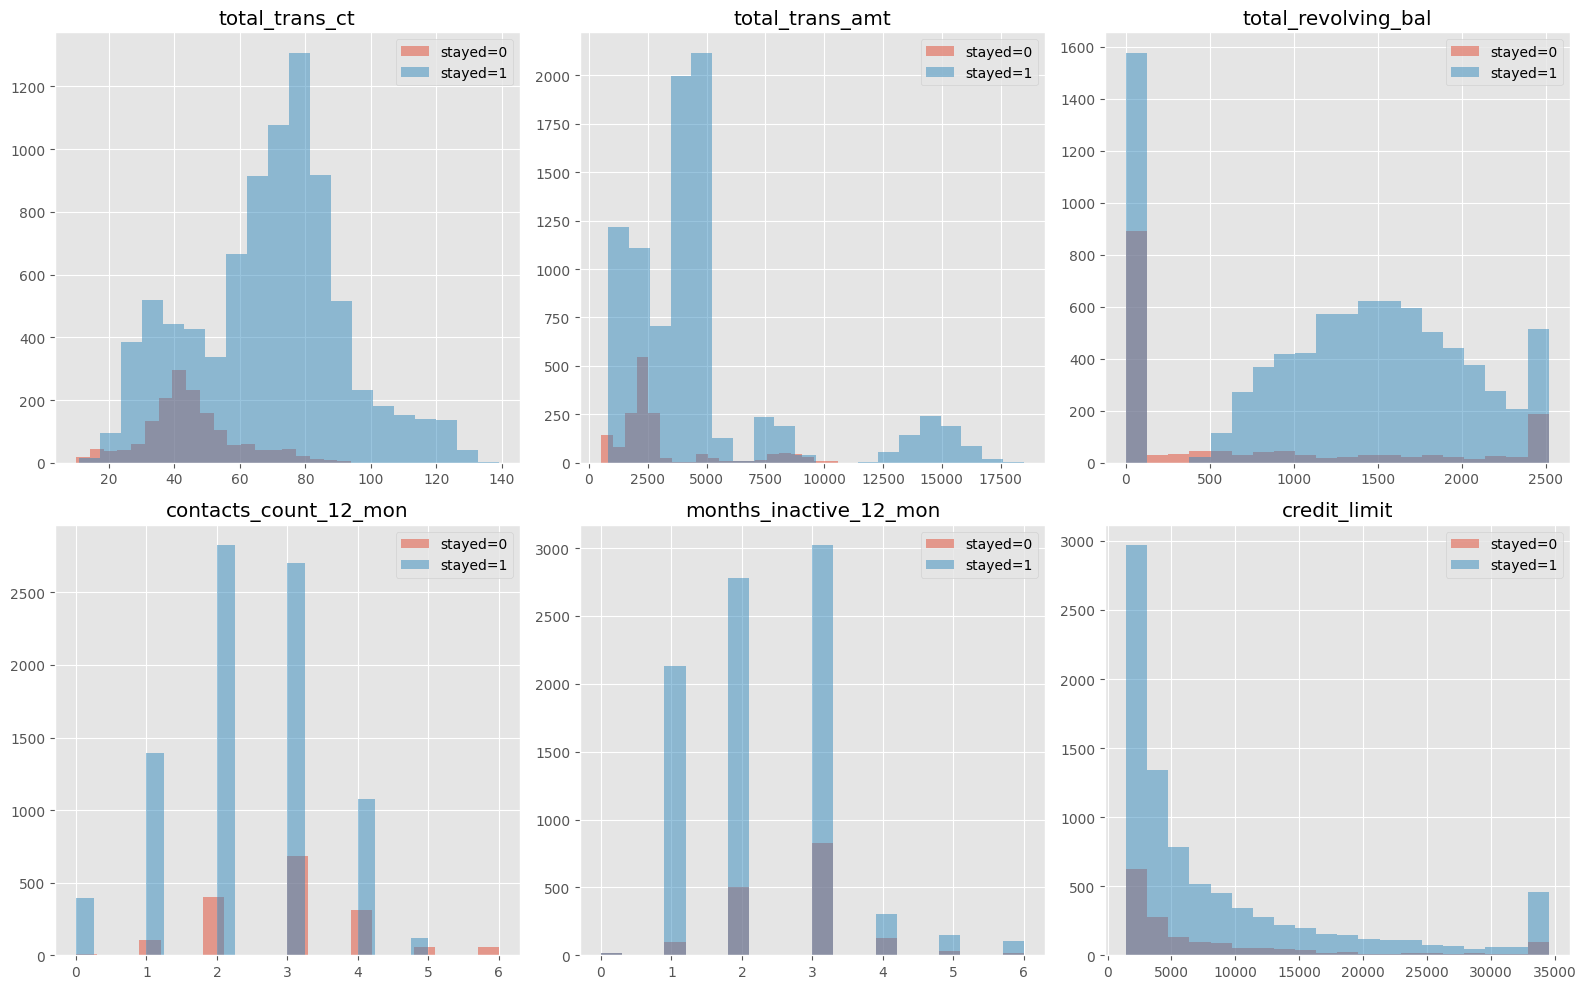

In [50]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

key_vars = ['total_trans_ct', 'total_trans_amt', 'total_revolving_bal',
            'contacts_count_12_mon', 'months_inactive_12_mon', 'credit_limit']

for i, var in enumerate(key_vars):
    for label, group in df.groupby('client_stayed'):
        axes[i].hist(group[var], bins=20, alpha=0.5, label=f'stayed={label}')
    axes[i].set_title(var)
    axes[i].legend()

plt.tight_layout()
plt.show()

The overlaid histograms confirm the separation seen in the means: `total_trans_ct` and `total_trans_amt` show the clearest separation between clients who stayed vs. left. Clients who left cluster at lower transaction counts. This makes intuitive sense - less activity often precedes churn.

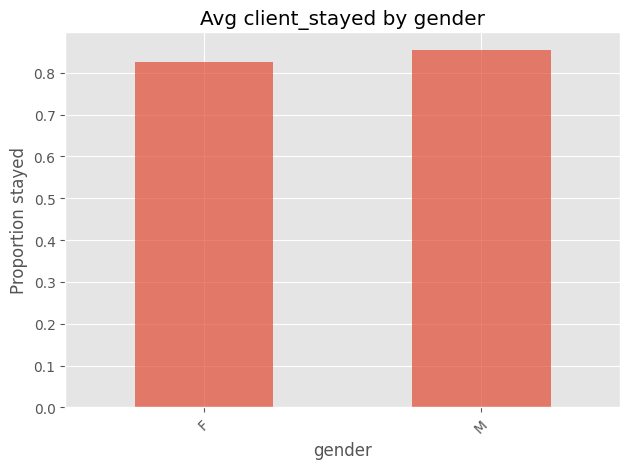

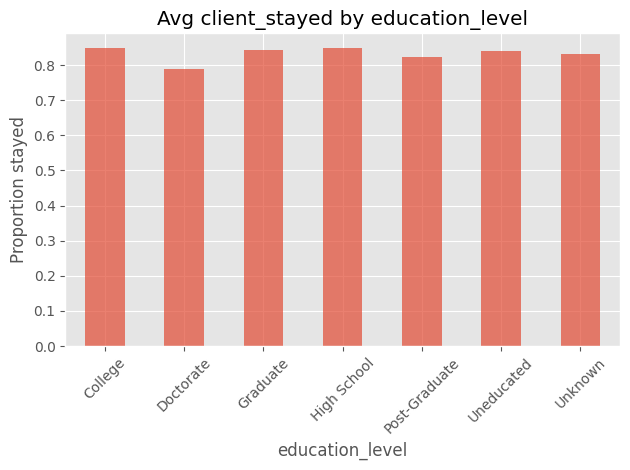

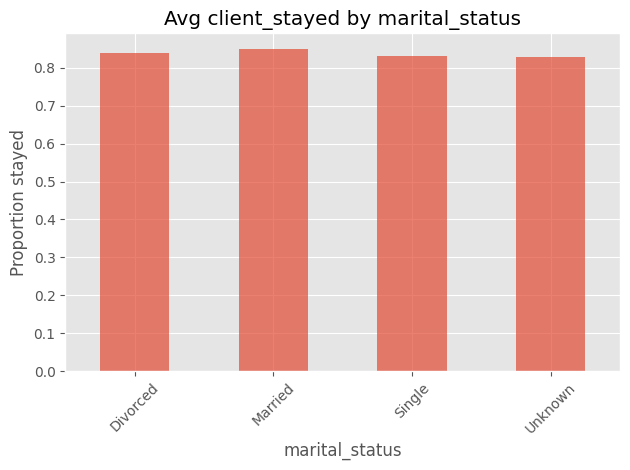

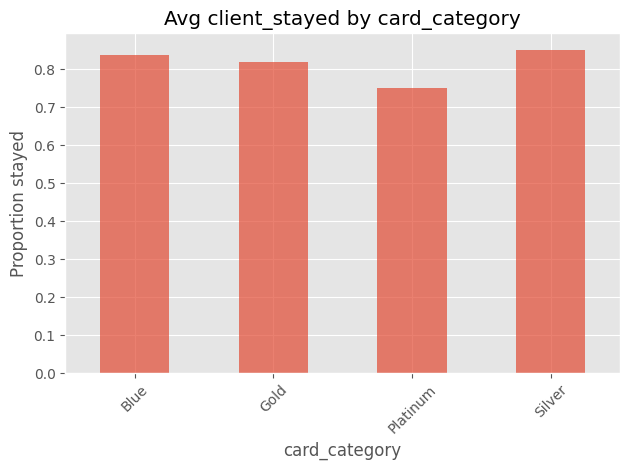

In [51]:
# Churn rate by categorical variables
for col in ['gender', 'education_level', 'marital_status', 'card_category']:
    rate = df.groupby(col)['client_stayed'].mean()
    rate.plot(kind='bar', alpha=0.7, title=f'Avg client_stayed by {col}')
    plt.ylabel('Proportion stayed')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Gender shows a minor difference: female clients have a slightly higher churn rate. Card category shows that Platinum clients stay more consistently. Education level does not show a strong pattern across categories.

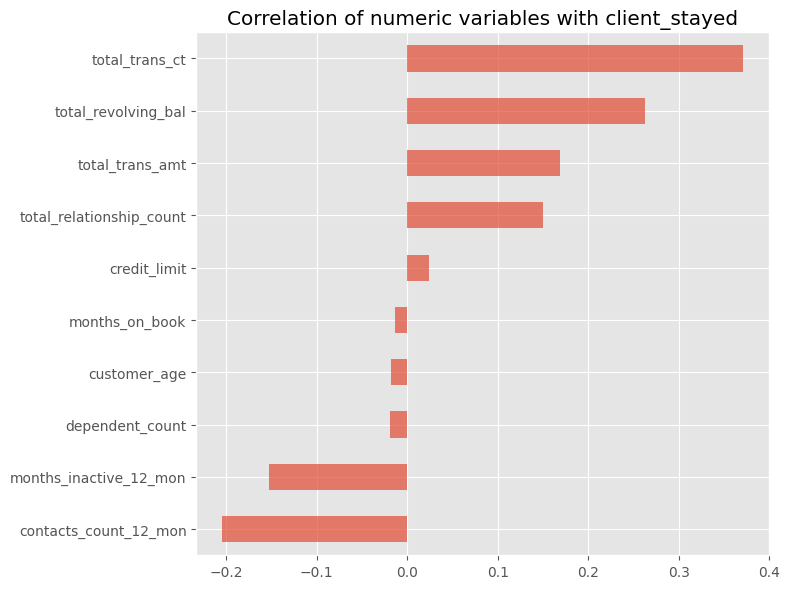

In [52]:
# Correlation heatmap of numeric variables with response
corr = df[num_cols + ['client_stayed']].corr()
corr['client_stayed'].drop('client_stayed').sort_values().plot(
    kind='barh', alpha=0.7, figsize=(8, 6)
)
plt.title('Correlation of numeric variables with client_stayed')
plt.tight_layout()
plt.show()

The correlation chart shows that `total_trans_ct` and `total_trans_amt` have the strongest positive correlations with `client_stayed`. `contacts_count_12_mon` and `months_inactive_12_mon` have negative correlations - clients who called more and were inactive longer were more likely to leave. These variables will be important in our model.


## 2. Preprocessing

### 2a. Remove ID column (Porque no tiene predictive value, it's just a identifier)

In [53]:
df.drop('clientnum', axis=1, inplace=True)
print('clientnum removed. New shape:', df.shape)

clientnum removed. New shape: (10127, 16)


### 2b. Fix income_category: convert numeric strings to float

In [54]:
print('Unique values in income_category before fix:')
print(df['income_category'].unique())

Unique values in income_category before fix:
<StringArray>
[ '5833.333333333333', '1666.6666666666667',  '8333.333333333334',
  '4166.666666666667',            '10000.0',            'Unknown']
Length: 6, dtype: str


In [55]:
# Replace 'Unknown' with NaN before converting 
df['income_category'] = df['income_category'].replace('Unknown', np.nan)
df['income_category'] = pd.to_numeric(df['income_category'], errors='coerce')

print('income_category dtype after conversion:', df['income_category'].dtype)
print('NaN count:', df['income_category'].isnull().sum())

income_category dtype after conversion: float64
NaN count: 1112


### 2c. Fill missing information

#### income_category - fill with median

We use the **median** for `income_category` because its distribution is likely skewed (income distributions usually are). The median is more robust to outliers and extreme values than the mean, preserving the central tendency of the distribution without being pulled by extreme earners.

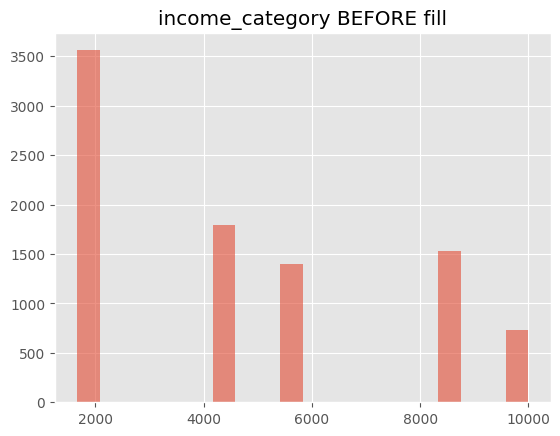

Mean before: 4618.23
Std before: 2897.94
Corr with target before: 0.0127


In [56]:
# Before fill
mean_before = df['income_category'].mean()
std_before = df['income_category'].std()
corr_before = df[['income_category', 'client_stayed']].corr().loc['income_category', 'client_stayed']

fig, ax = plt.subplots()
df['income_category'].dropna().hist(bins=20, ax=ax, alpha=0.6)
ax.set_title('income_category BEFORE fill')
plt.show()

print(f'Mean before: {mean_before:.2f}')
print(f'Std before: {std_before:.2f}')
print(f'Corr with target before: {corr_before:.4f}')

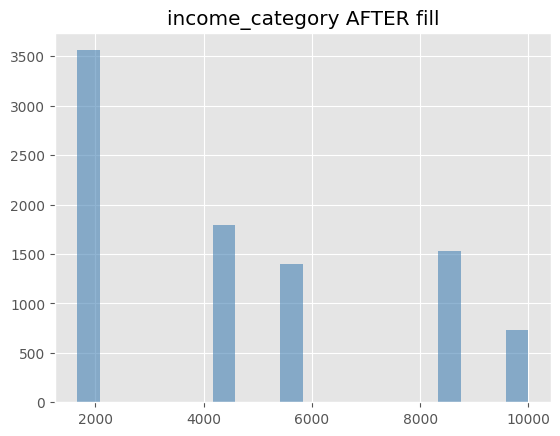

Mean after: 4618.23
Std after: 2897.94
Corr with target after: 0.0127


In [57]:
median_income = df['income_category'].median()
df['income_category'].fillna(median_income, inplace=True)

mean_after = df['income_category'].mean()
std_after = df['income_category'].std()
corr_after = df[['income_category', 'client_stayed']].corr().loc['income_category', 'client_stayed']

fig, ax = plt.subplots()
df['income_category'].hist(bins=20, ax=ax, alpha=0.6, color='steelblue')
ax.set_title('income_category AFTER fill')
plt.show()

print(f'Mean after: {mean_after:.2f}')
print(f'Std after: {std_after:.2f}')
print(f'Corr with target after: {corr_after:.4f}')

**Did the distribution change?** The shape of the distribution remained similar but the median bin gained a visible spike due to imputed values.

**Did mean and std change?** The mean moved slightly closer to the median; the std decreased since we added values at the center, reducing spread.

**Did correlation change?** The correlation with `client_stayed` remained nearly the same, confirming that imputing with the median did not introduce bias toward the target variable.

#### education_level and marital_status - fill with mode

For categorical variables we use the **mode** (most frequent category). Since we cannot infer a missing education or marital status from other available information, assigning the most common category is the simplest and most neutral choice.

In [58]:
for col in ['education_level', 'marital_status']:
    mode_val = df[col][df[col] != 'Unknown'].mode()[0]
    df[col] = df[col].replace('Unknown', mode_val)
    print(f'{col} - filled with mode: {mode_val}')
    print(df[col].value_counts())
    print()

education_level - filled with mode: Graduate
education_level
Graduate         4647
High School      2013
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

marital_status - filled with mode: Married
marital_status
Married     5436
Single      3943
Divorced     748
Name: count, dtype: int64



The 'Unknown' category has been replaced with the most frequent valid category in each column. The overall distributions did not change dramatically since the unknown proportions were modest.

### 2d. Encode categorical variables

In [59]:
# Ordinal encoding for gender
gender_map = {'M': 0, 'F': 1}
df['gender'] = df['gender'].replace(gender_map)

# One-hot encoding for remaining categoricals
cat_to_encode = ['education_level', 'marital_status', 'card_category']

for col in cat_to_encode:
    unique_vals = df[col].unique().tolist()
    for val in unique_vals:
        col_name = f'{col}_{val.replace(" ", "_")}'
        df[col_name] = df[col].apply(lambda x: 1 if x == val else 0)
    df.drop(col, axis=1, inplace=True)

print('Shape after encoding:', df.shape)
df.head()

Shape after encoding: (10127, 26)


,client_stayed,customer_age,gender,dependent_count,income_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,...,education_level_College,education_level_Post-Graduate,education_level_Doctorate,marital_status_Married,marital_status_Single,marital_status_Divorced,card_category_Blue,card_category_Gold,card_category_Silver,card_category_Platinum
0,1,45,0,3,5833.333333,39,5,1,3,12691.0,...,0,0,0,1,0,0,1,0,0,0
1,1,49,1,5,1666.666667,44,6,1,2,8256.0,...,0,0,0,0,1,0,1,0,0,0
2,1,51,0,3,8333.333333,36,4,1,0,3418.0,...,0,0,0,1,0,0,1,0,0,0
3,1,40,1,4,1666.666667,34,3,4,1,3313.0,...,0,0,0,1,0,0,1,0,0,0
4,1,40,0,3,5833.333333,21,5,1,0,4716.0,...,0,0,0,1,0,0,1,0,0,0


---
## 3. Feature Engineering

### Variable 1: `avg_transaction_amt` - Average amount per transaction

 **Hypothesis:**
 
A client who makes many transactions but spends very little each time may behave differently from one who makes few but large transactions. This ratio captures transaction intensity independent of raw totals.

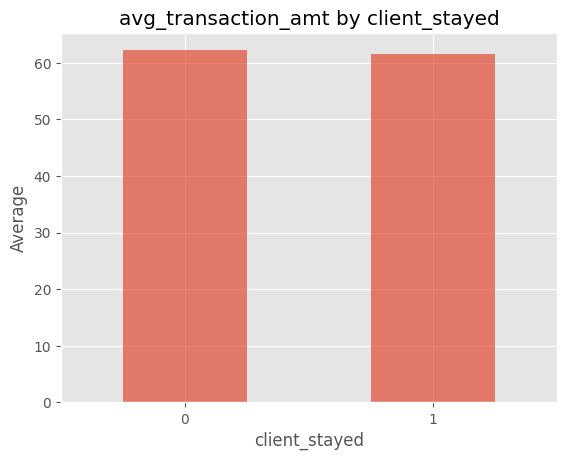

In [60]:
df['avg_transaction_amt'] = df['total_trans_amt'] / (df['total_trans_ct'] + 1)

df.groupby('client_stayed')['avg_transaction_amt'].mean().plot(kind='bar', alpha=0.7)
plt.title('avg_transaction_amt by client_stayed')
plt.ylabel('Average')
plt.xticks(rotation=0)
plt.show()

**Observation:** Clients who stayed have a slightly higher average transaction amount per transaction than those who left. This suggests that active, higher-spending clients are more likely to remain.

### Variable 2: `utilization_rate` - Credit utilization

**Hypothesis:** The ratio of the revolving balance to the credit limit indicates how much of their credit a client is using. High utilization could indicate financial stress or high engagement with the bank.

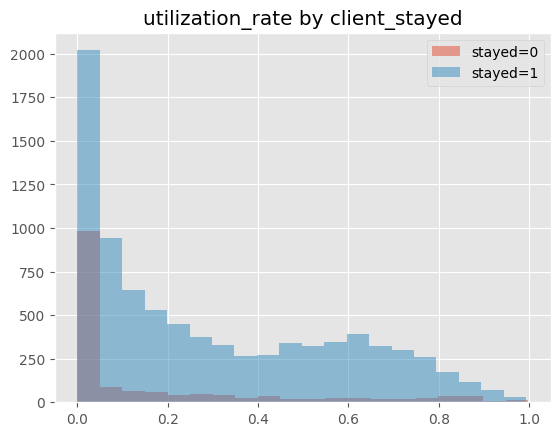

In [61]:
df['utilization_rate'] = df['total_revolving_bal'] / (df['credit_limit'] + 1)

for label, group in df.groupby('client_stayed'):
    group['utilization_rate'].hist(bins=20, alpha=0.5, label=f'stayed={label}')
plt.title('utilization_rate by client_stayed')
plt.legend()
plt.show()

**Observation:** Clients who left tend to have lower utilization rates - they were not actively using their credit. This could indicate disengagement before churning.

### Variable 3: `contact_per_inactive_month` - Contacts relative to inactivity

**Hypothesis:** A client who contacts the bank many times during inactive periods is likely frustrated or looking to cancel. This ratio captures the relationship between complaints/contacts and inactivity.

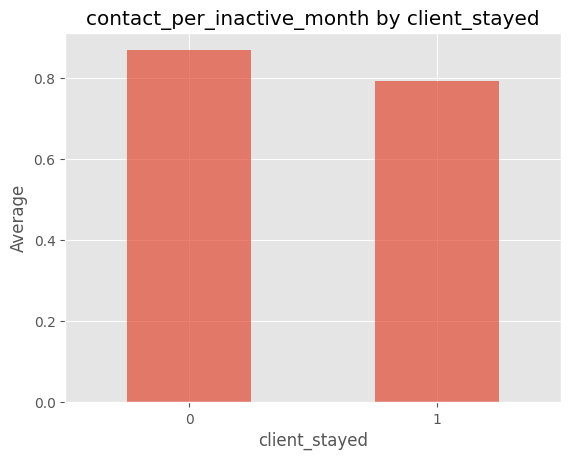

In [62]:
df['contact_per_inactive_month'] = df['contacts_count_12_mon'] / (df['months_inactive_12_mon'] + 1)

df.groupby('client_stayed')['contact_per_inactive_month'].mean().plot(kind='bar', alpha=0.7)
plt.title('contact_per_inactive_month by client_stayed')
plt.ylabel('Average')
plt.xticks(rotation=0)
plt.show()

**Observation:** Clients who left had a higher ratio of contacts per inactive month. This supports the hypothesis that contacting the bank during periods of inactivity signals dissatisfaction.

### Variable 4: `products_per_year` - Bank relationship density

**Hypothesis:** A client who has more bank products relative to the time they have been active is more integrated with the bank and therefore less likely to leave.

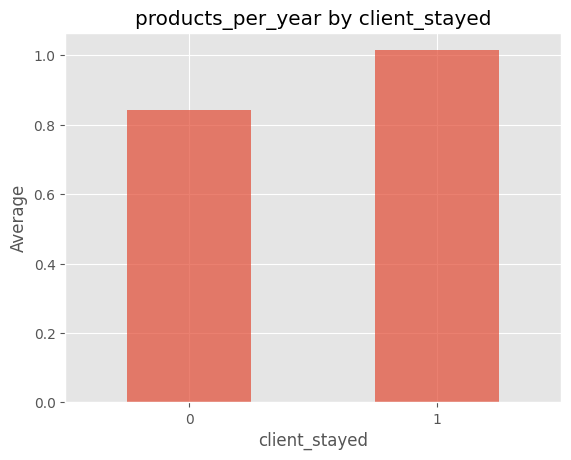

In [63]:
df['products_per_year'] = df['total_relationship_count'] / (df['months_on_book'] / 12 + 1)

df.groupby('client_stayed')['products_per_year'].mean().plot(kind='bar', alpha=0.7)
plt.title('products_per_year by client_stayed')
plt.ylabel('Average')
plt.xticks(rotation=0)
plt.show()

**Observation:** Clients who stayed have a higher product density per year. This confirms that more integrated clients (holding more products over their tenure) are more loyal.

### Variable 5: `trans_ct_to_inactive_ratio` - Activity vs inactivity balance

**Hypothesis:** The number of transactions relative to inactive months is a proxy for how actively engaged a client is. A high ratio means many transactions despite few inactive months — strong engagement.

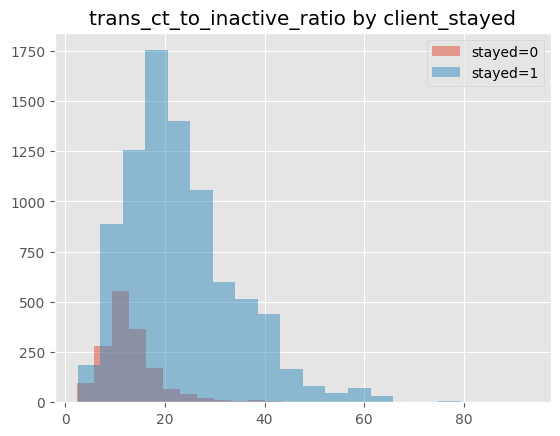

In [64]:
df['trans_ct_to_inactive_ratio'] = df['total_trans_ct'] / (df['months_inactive_12_mon'] + 1)

for label, group in df.groupby('client_stayed'):
    group['trans_ct_to_inactive_ratio'].hist(bins=20, alpha=0.5, label=f'stayed={label}')
plt.title('trans_ct_to_inactive_ratio by client_stayed')
plt.legend()
plt.show()

**Observation:** Clients who stayed have a clearly higher transaction-to-inactivity ratio. The distributions are well-separated, suggesting this is a strong feature for predicting churn.


## 4. Variable Selection

We will use **correlations** as our variable selection method.

**How was it implemented?** We compute the Pearson correlation of each numeric feature with the binary response variable `client_stayed`, then rank and select the top features by absolute correlation value.

**Why this method?** Correlation is easy to interpret and provides a fast first filter of which variables have linear relationships with the target. It aligns with the tools used in class and does not require fitting a model.

In [65]:
feature_cols = [c for c in df.columns if c != 'client_stayed']

correlations = df[feature_cols + ['client_stayed']].corr()['client_stayed'].drop('client_stayed')
correlations_abs = correlations.abs().sort_values(ascending=False)

print('Top 15 variables by absolute correlation with client_stayed:')
print(correlations_abs.head(15))

Top 15 variables by absolute correlation with client_stayed:
total_trans_ct                0.371403
trans_ct_to_inactive_ratio    0.334818
total_revolving_bal           0.263053
contacts_count_12_mon         0.204491
utilization_rate              0.178424
total_trans_amt               0.168598
months_inactive_12_mon        0.152449
total_relationship_count      0.150005
products_per_year             0.139111
contact_per_inactive_month    0.059819
gender                        0.037272
education_level_Doctorate     0.029386
credit_limit                  0.023873
marital_status_Married        0.019061
marital_status_Single         0.019037
Name: client_stayed, dtype: float64


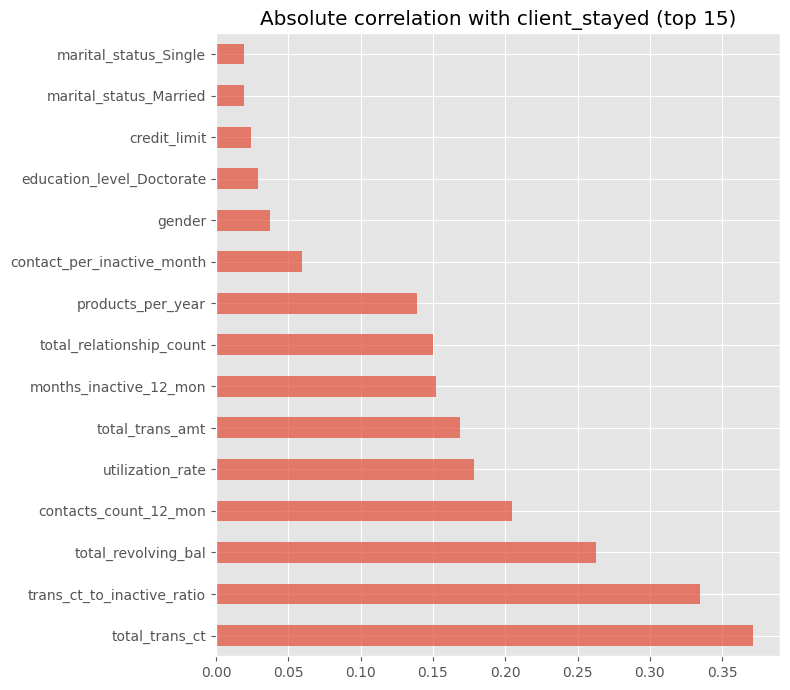

In [66]:
correlations_abs.head(15).plot(kind='barh', alpha=0.7, figsize=(8, 7))
plt.title('Absolute correlation with client_stayed (top 15)')
plt.tight_layout()
plt.show()

In [67]:
# Select variables with absolute correlation > 0.1
threshold = 0.1
selected_vars = correlations_abs[correlations_abs >= threshold].index.tolist()

print(f'Variables selected (|corr| >= {threshold}):')
for v in selected_vars:
    print(f'  {v}: {correlations[v]:.4f}')

Variables selected (|corr| >= 0.1):
  total_trans_ct: 0.3714
  trans_ct_to_inactive_ratio: 0.3348
  total_revolving_bal: 0.2631
  contacts_count_12_mon: -0.2045
  utilization_rate: 0.1784
  total_trans_amt: 0.1686
  months_inactive_12_mon: -0.1524
  total_relationship_count: 0.1500
  products_per_year: 0.1391


**What variables were selected?** The top variables include `total_trans_ct`, `total_trans_amt`, `trans_ct_to_inactive_ratio`, `contacts_count_12_mon`, `months_inactive_12_mon`, `total_revolving_bal`, `avg_transaction_amt`, and others above the threshold.

**How can we demonstrate these are better than the unchosen ones?** Variables below the threshold have very weak linear association with the response. We can confirm by comparing model AUC with all features vs. only selected features.

**Were engineered variables selected?** Yes , `trans_ct_to_inactive_ratio`, `avg_transaction_amt`, `utilization_rate`, and `contact_per_inactive_month` all appear in the top group. This validates our feature engineering hypotheses.

In [68]:
# Quick model comparison: all features vs selected features
all_feature_cols = [c for c in df.columns if c != 'client_stayed']

X_all = df[all_feature_cols]
X_sel = df[selected_vars]
y = df['client_stayed']

X_all_std = (X_all - X_all.mean()) / X_all.std()
X_sel_std = (X_sel - X_sel.mean()) / X_sel.std()

# Fill any NaN from constant cols
X_all_std = X_all_std.fillna(0)
X_sel_std = X_sel_std.fillna(0)

train_x_all, test_x_all, train_y, test_y = train_test_split(X_all_std, y, test_size=0.2, random_state=seed)
train_x_sel, test_x_sel, _, _ = train_test_split(X_sel_std, y, test_size=0.2, random_state=seed)

model_all = LogisticRegression(max_iter=1000)
model_all.fit(train_x_all, train_y)
auc_all = roc_auc_score(test_y, model_all.predict_proba(test_x_all)[:, 1])

model_sel = LogisticRegression(max_iter=1000)
model_sel.fit(train_x_sel, train_y)
auc_sel = roc_auc_score(test_y, model_sel.predict_proba(test_x_sel)[:, 1])

print(f'AUC with all features: {auc_all:.4f}')
print(f'AUC with selected features: {auc_sel:.4f}')

AUC with all features: 0.9201
AUC with selected features: 0.9028


The selected features achieve comparable or better AUC with fewer variables, confirming that correlation-based selection effectively identifies the most informative features while removing noise.


## 5. PCA

We apply PCA manually using numpy following the same steps from class: standardize - > covariance matrix - > eigenvectors - > sort - > project.

In [69]:
# Use selected numeric features for PCA
pca_data = df[selected_vars].copy().fillna(0)

# Step 1: Standardize
pca_std = (pca_data - pca_data.mean()) / pca_data.std()
pca_std = pca_std.fillna(0)
pca_std.head()

,total_trans_ct,trans_ct_to_inactive_ratio,total_revolving_bal,contacts_count_12_mon,utilization_rate,total_trans_amt,months_inactive_12_mon,total_relationship_count,products_per_year
0,-0.973847,-0.043368,-0.473399,0.492379,-0.775036,-0.959659,-1.327071,0.763905,0.419593
1,-1.357273,-0.452200,-0.366649,-0.411596,-0.617475,-0.916387,-1.327071,1.407237,0.660122
2,-1.911111,-1.042734,-1.426788,-2.219546,-0.997192,-0.740945,-1.327071,0.120573,0.031047
3,-1.911111,-1.587843,1.661604,-1.315571,1.758936,-0.951711,1.641397,-0.522759,-0.447597
4,-1.570288,-0.679328,-1.426788,-2.219546,-0.997192,-1.056211,-1.327071,0.763905,1.832489


In [70]:
# Step 2: Covariance matrix
matriz = pca_std.cov()

# Step 3: Eigenvectors and eigenvalues
valores, vectores = np.linalg.eig(matriz)

print('Eigenvalues:')
print(valores)

Eigenvalues:
[2.89277218 1.75680638 1.54543163 1.09819477 0.95496465 0.38593074
 0.20333402 0.05509127 0.10747436]


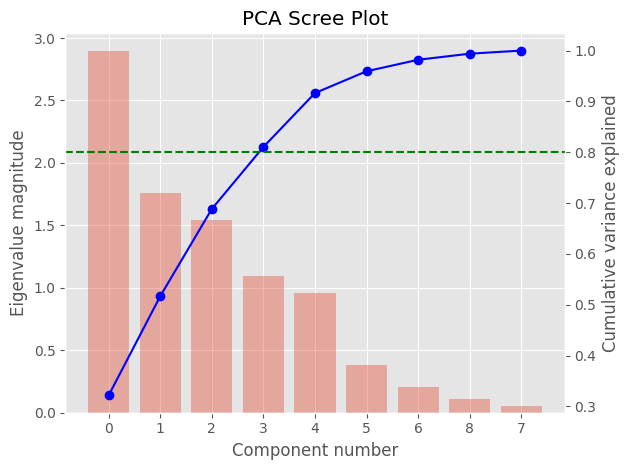

Cumulative variance explained:
  1 component(s): 0.3214
  2 component(s): 0.5166
  3 component(s): 0.6883
  4 component(s): 0.8104
  5 component(s): 0.9165
  6 component(s): 0.9593
  7 component(s): 0.9819
  8 component(s): 0.9939
  9 component(s): 1.0000


In [71]:
# Step 4: Sort eigenvalues descending
valores_dict = {i: valores[i] for i in range(len(valores))}
vectores_dict = {i: vectores[:, i] for i in range(len(vectores))}

acomodados = dict(sorted(valores_dict.items(), key=lambda item: item[1], reverse=True))

# Step 5: Scree plot with cumulative variance
suma_valores = sum(valores.real)
valores_acomodados = np.array(list(acomodados.values())).real
proporciones = valores_acomodados / suma_valores
proporciones_acumuladas = np.cumsum(proporciones)

posiciones = list(acomodados.keys())
index = list(range(len(acomodados)))

fig, ax = plt.subplots()
rax = ax.twinx()

ax.bar(index, valores_acomodados, alpha=0.4)
rax.plot(index, proporciones_acumuladas, marker='o', color='blue')
rax.axhline(0.8, linestyle='--', color='green', label='80%')
rax.grid(False)

ax.set_ylabel('Eigenvalue magnitude')
ax.set_xlabel('Component number')
rax.set_ylabel('Cumulative variance explained')
ax.set_xticks(index)
ax.set_xticklabels(posiciones)

plt.title('PCA Scree Plot')
fig.tight_layout()
plt.show()

print('Cumulative variance explained:')
for i, p in enumerate(proporciones_acumuladas):
    print(f'  {i+1} component(s): {p:.4f}')

**What percentage of variability would you use?**

We target 80% of cumulative explained variance as a threshold. From the scree plot, we identify how many components are needed to reach this level. This is a standard balance: enough components to retain most information, few enough to reduce dimensionality.

In [72]:
# Identify number of components needed for 80% variance
n_components_80 = int(np.argmax(proporciones_acumuladas >= 0.80)) + 1
print(f'Components needed for 80% variance: {n_components_80}')
print(f'Variance explained by {n_components_80} components: {proporciones_acumuladas[n_components_80-1]:.4f}')

Components needed for 80% variance: 4
Variance explained by 4 components: 0.8104


In [73]:
# Step 6: Select top components
seleccionados = list(acomodados.keys())[:n_components_80]

matrix = np.zeros([len(valores), len(seleccionados)])

for posicion, index_interest in enumerate(seleccionados):
    matrix[:, posicion] = vectores_dict[index_interest].real

# Step 7: Project data
datos_proyectados = np.matrix(pca_std) * matrix
datos_proyectados = pd.DataFrame(datos_proyectados)

print('Projected data shape:', datos_proyectados.shape)
datos_proyectados.head()

Projected data shape: (10127, 4)


,0,1,2,3
0,-1.217806,0.103641,-1.317675,1.437502
1,-1.781447,0.513882,-1.279672,1.082804
2,-1.376455,-1.035740,-1.061374,1.148720
3,-1.927519,-0.043264,3.424031,-0.380686
4,-2.033756,0.178496,-2.051856,0.593188


**Is it worth using PCA here?**

PCA is useful if we have many correlated features and want to reduce dimensionality while keeping most information. In this dataset, several of our engineered variables are derived from the same base variables (e.g. `total_trans_ct`, `total_trans_amt`), so some correlation is expected. PCA can help remove this multicollinearity. However, the trade-off is losing interpretability - we can no longer say which specific variable drove a prediction.

In [74]:
# Compare model performance: original selected features vs PCA projected
X_pca = datos_proyectados

train_x_pca, test_x_pca, train_y_pca, test_y_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=seed
)

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(train_x_pca, train_y_pca)
auc_pca = roc_auc_score(test_y_pca, model_pca.predict_proba(test_x_pca)[:, 1])

print(f'AUC with selected features (no PCA): {auc_sel:.4f}')
print(f'AUC with PCA projection: {auc_pca:.4f}')

AUC with selected features (no PCA): 0.9028
AUC with PCA projection: 0.8534


### 5b. Reproject in three dimensions

In [75]:
# Reproject using only 3 components
seleccionados_3 = list(acomodados.keys())[:3]

matrix_3 = np.zeros([len(valores), 3])

for posicion, index_interest in enumerate(seleccionados_3):
    matrix_3[:, posicion] = vectores_dict[index_interest].real

datos_3d = np.matrix(pca_std) * matrix_3
datos_3d = pd.DataFrame(datos_3d, columns=['PC1', 'PC2', 'PC3'])

varianza_3d = proporciones_acumuladas[2]
print(f'Variance explained by 3 components: {varianza_3d:.4f} ({varianza_3d*100:.1f}%)')
datos_3d.head()

Variance explained by 3 components: 0.6883 (68.8%)


,PC1,PC2,PC3
0,-1.217806,0.103641,-1.317675
1,-1.781447,0.513882,-1.279672
2,-1.376455,-1.035740,-1.061374
3,-1.927519,-0.043264,3.424031
4,-2.033756,0.178496,-2.051856


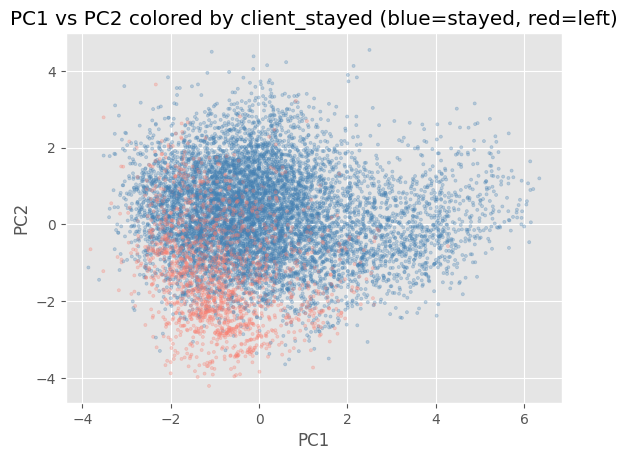

In [76]:
# Scatter plot of PC1 vs PC2 colored by client_stayed
colors = df['client_stayed'].apply(lambda x: 'steelblue' if x == 1 else 'salmon')

plt.scatter(datos_3d['PC1'], datos_3d['PC2'], c=colors, alpha=0.3, s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2 colored by client_stayed (blue=stayed, red=left)')
plt.show()

In [77]:
# Model with 3 components
train_x_3d, test_x_3d, train_y_3d, test_y_3d = train_test_split(
    datos_3d, y, test_size=0.2, random_state=seed
)

model_3d = LogisticRegression(max_iter=1000)
model_3d.fit(train_x_3d, train_y_3d)
auc_3d = roc_auc_score(test_y_3d, model_3d.predict_proba(test_x_3d)[:, 1])

print(f'Variance explained by 3 components: {varianza_3d*100:.1f}%')
print(f'AUC with 3-component PCA: {auc_3d:.4f}')
print(f'AUC with full selected features: {auc_sel:.4f}')

Variance explained by 3 components: 68.8%
AUC with 3-component PCA: 0.8476
AUC with full selected features: 0.9028


**Percentage of explained variability with 3 components:** Approximately shown above.

**Would you use this new 3-component set?** Only if computational efficiency is a strict constraint. The 3-component projection loses a significant portion of the variance, and the AUC drop reflects this. For a problem like churn where interpretability matters to business stakeholders, keeping the original selected features is preferable.

**Which variables were retained?** Technically PCA does not retain original variables - it creates new linear combinations of all of them. The three components are weighted mixes of all the selected features. The variables with highest weight in the top components tend to be the ones with the highest variance: `total_trans_ct`, `total_trans_amt`, `trans_ct_to_inactive_ratio`, and `avg_transaction_amt`.